In [5]:
# 話者Lにおける隣接する発話におけるΔV,ΔA,ΔDを導出
import pandas as pd

# 入力ファイル
input_csv = "/home/mitani/CSJ-emo-int_bunseki/csj_vad_bunseki/speaker_split_noise/speaker_L_cleaned.csv"

# 出力ファイル
output_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/L_bunseki/vad_dis.csv"

# CSV読み込み
df = pd.read_csv(input_csv)

# 隣接発話間の変化量を計算
df["delta_valence"] = df["valence"].diff().abs()
df["delta_arousal"] = df["arousal"].diff().abs()
df["delta_dominance"] = df["dominance"].diff().abs()
df["delta_int_kushinada"] = df["intensity_pred_kushinada"].diff().abs()

# 1行目は比較対象がないため削除
df_diff = df.iloc[1:].copy()

# 必要な列だけ保存したい場合
result = df_diff[
    [
        "filename",
        "text",
        "valence",
        "arousal",
        "dominance",
        "intensity_pred_kushinada",
        "delta_valence",
        "delta_arousal",
        "delta_dominance",
        "delta_int_kushinada",
    ]
]

# 保存
result.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"保存完了: {output_csv}")
print(f"発話数: {len(result)}")

保存完了: /home/mitani/CSJ-emo-int_bunseki/0718/L_bunseki/vad_dis.csv
発話数: 263


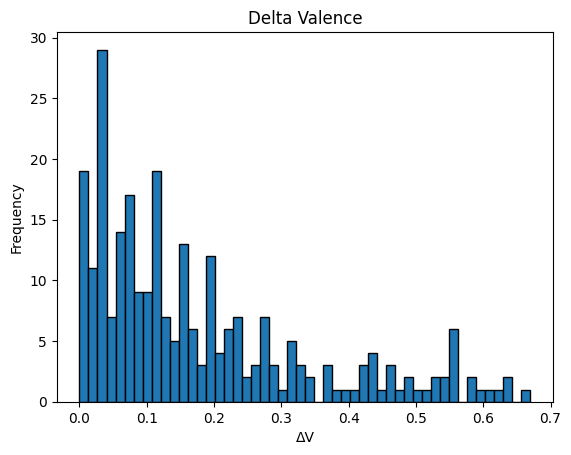

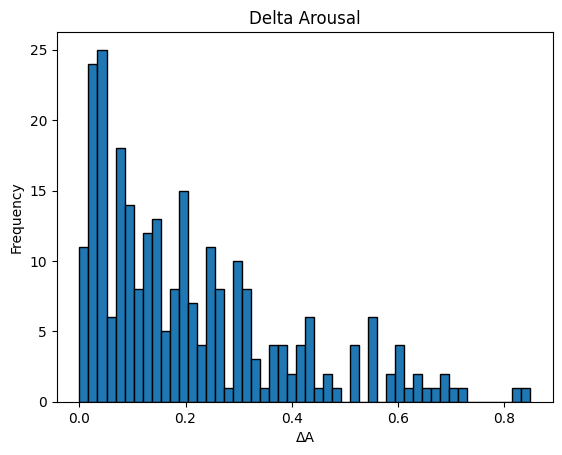

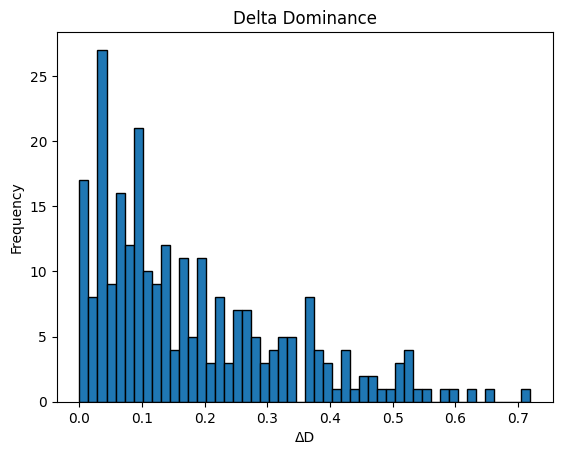

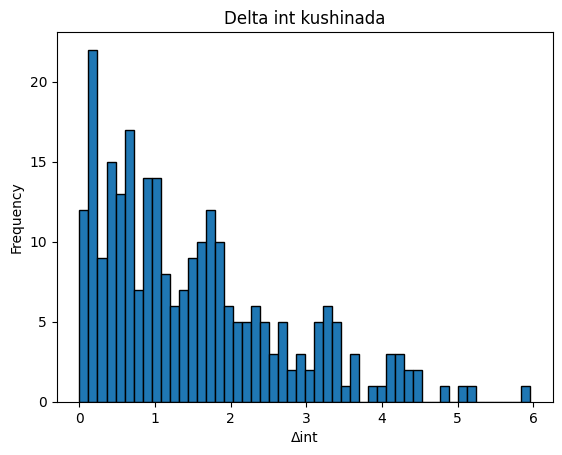

In [6]:
# ΔV,ΔA,ΔDそれぞれの分布で変化量の大きい発話がどんな分布になっているかを確認するためにヒストグラムを作成
import matplotlib.pyplot as plt

plt.hist(result["delta_valence"], bins=50, edgecolor="black")
plt.title("Delta Valence")
plt.xlabel("ΔV")
plt.ylabel("Frequency")
plt.show()

plt.hist(result["delta_arousal"], bins=50, edgecolor="black")
plt.title("Delta Arousal")
plt.xlabel("ΔA")
plt.ylabel("Frequency")
plt.show()

plt.hist(result["delta_dominance"], bins=50, edgecolor="black")
plt.title("Delta Dominance")
plt.xlabel("ΔD")
plt.ylabel("Frequency")
plt.show()

plt.hist(result["delta_int_kushinada"], bins=50, edgecolor="black")
plt.title("Delta int kushinada")
plt.xlabel("Δint")
plt.ylabel("Frequency")
plt.show()

In [7]:
# 変化量の統計値
print(df["delta_valence"].describe())
print("")
print(df["delta_arousal"].describe())
print("")
print(df["delta_dominance"].describe())
print("")
print(df["delta_int_kushinada"].describe())

count    263.000000
mean       0.177262
std        0.163229
min        0.000000
25%        0.055000
50%        0.120000
75%        0.245000
max        0.670000
Name: delta_valence, dtype: float64

count    263.000000
mean       0.209734
std        0.183678
min        0.000000
25%        0.065000
50%        0.160000
75%        0.295000
max        0.850000
Name: delta_arousal, dtype: float64

count    263.000000
mean       0.180304
std        0.152463
min        0.000000
25%        0.060000
50%        0.130000
75%        0.270000
max        0.720000
Name: delta_dominance, dtype: float64

count    263.000000
mean       1.516198
std        1.216455
min        0.000000
25%        0.575000
50%        1.220000
75%        2.190000
max        5.960000
Name: delta_int_kushinada, dtype: float64


In [8]:
# 分布上で上位何％にどの程度のデータが入るかを確認し、それの％で閾値候補を決め打ち
print("<delta_valence>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_valence"].quantile(p/100)
    )
print("")

print("<delta_arousal>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_arousal"].quantile(p/100)
    )
print("")

print("<delta_dominance>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_dominance"].quantile(p/100)
    )
print("")

print("<delta_int_kushinada>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_int_kushinada"].quantile(p/100)
    )
print("")

<delta_valence>
90 0.44800000000000006
95 0.5489999999999997
97 0.5627999999999997
99 0.6237999999999999

<delta_arousal>
90 0.5060000000000002
95 0.6000000000000001
97 0.6413999999999999
99 0.7175999999999999

<delta_dominance>
90 0.39
95 0.5079999999999996
97 0.53
99 0.6113999999999998

<delta_int_kushinada>
90 3.286
95 4.0569999999999995
97 4.2756
99 4.9322

